# NB19: Mengapa O-Token MTL Berkumpul?
## Penjelasan Visual Cross-Attention dan Efek Averaging

Di NB18 kita menemukan fenomena ini:
- **MTL**: token O terlihat *berkumpul* di satu area di t-SNE
- **STL**: token O *tersebar* ke seluruh penjuru plot

Notebook ini menjelaskan mekanisme di baliknya, step-by-step:

```
Bagian 1: Cross-attention menghitung apa? → heatmap attention
Bagian 2: Token O tidak punya 'jangkar' → distribusi entropi
Bagian 3: Efek averaging → demo 2D sintetis
Bagian 4: Konfirmasi data nyata → scatter entropi vs jarak centroid
Bagian 5: MT vs ST side-by-side → t-SNE anotasi + rekonsiliasi paradoks
```

**Formula cross-attention (inti notebook ini):**
$$h_{sd}[i] = \sum_j \text{attn}(i,j) \times h_{sl}[j]$$

Dimana bobot attention dihitung dari:
$$\text{attn}(i,j) = \text{softmax}\left(w_s^T \tanh(W_{ae} h_{ae}[i] + W_{sl} h_{sl}[j] + W_{pos} p_{ij})\right)$$

Jadi $h_{sd}[i]$ adalah **rata-rata tertimbang** dari semua $h_{sl}[j]$ dalam kalimat.

In [18]:
import json
import os
import string
import gc

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Ellipse, FancyArrowPatch
import seaborn as sns
from collections import Counter
from scipy.stats import entropy as scipy_entropy
from transformers import AutoModel, AutoTokenizer
from torchcrf import CRF
from sklearn.manifold import TSNE
from sklearn.metrics.pairwise import cosine_distances

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 10

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

# Paths & Config
BASE_DIR = os.path.dirname(os.getcwd())
DATA_RAW_DIR = os.path.join(BASE_DIR, 'data', 'raw')
DATA_PROC_DIR = os.path.join(BASE_DIR, 'data', 'processed')
MODEL_DIR = os.path.join(BASE_DIR, 'models')

MODEL_NAME = 'indobenchmark/indobert-large-p2'
MAX_LENGTH = 128
PROJ_DIM = 256
DROPOUT = 0.1
MAX_REL_POS = 20
LAMBDA1 = 0.3
LAMBDA2 = 0.3
IGNORE_INDEX = -100
SEED = 42

torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
np.random.seed(SEED)

# Labels
ate_labels   = ['O', 'B', 'I', 'E', 'S']
sld_labels   = ['O', 'POS', 'NEG']
asd_labels   = ['O', 'POS', 'NEG', 'NEU']
bieos_labels = ['O', 'B-NEG', 'B-NEU', 'B-POS', 'E-NEG', 'E-NEU', 'E-POS',
                'I-NEG', 'I-NEU', 'I-POS', 'S-NEG', 'S-NEU', 'S-POS']

ate_label2id   = {l: i for i, l in enumerate(ate_labels)}
sld_label2id   = {l: i for i, l in enumerate(sld_labels)}
asd_label2id   = {l: i for i, l in enumerate(asd_labels)}
bieos_label2id = {l: i for i, l in enumerate(bieos_labels)}
bieos_id2label = {i: l for l, i in bieos_label2id.items()}

# Color scheme (consistent with NB18)
sentiment_colors = {'O': '#34495e', 'POS': '#2ecc71', 'NEG': '#e74c3c', 'NEU': '#3498db'}
model_colors = {'MT': '#e74c3c', 'ST': '#3498db'}

print('Config loaded.')

Device: cuda
GPU: NVIDIA GeForce RTX 4060 Laptop GPU
Config loaded.


In [19]:
# Model class definitions (identik dengan NB18)
class CrossAttentionASD(nn.Module):
    def __init__(self, dim, max_relative_position=20):
        super().__init__()
        self.max_rel_pos = max_relative_position
        self.pos_embedding = nn.Embedding(2 * max_relative_position + 1, dim)
        self.W_ae = nn.Linear(dim, dim, bias=False)
        self.W_sl = nn.Linear(dim, dim, bias=False)
        self.W_pos = nn.Linear(dim, dim, bias=False)
        self.bias = nn.Parameter(torch.zeros(dim))
        self.w_s = nn.Linear(dim, 1, bias=False)
        self.last_attn_weights = None

    def forward(self, h_ae, h_sl, mask=None):
        batch, seq_len, dim = h_ae.shape
        pos = torch.arange(seq_len, device=h_ae.device)
        rel_pos = (pos.unsqueeze(0) - pos.unsqueeze(1)).clamp(
            -self.max_rel_pos, self.max_rel_pos) + self.max_rel_pos
        p_ij = self.pos_embedding(rel_pos)
        s_ae = self.W_ae(h_ae)
        s_sl = self.W_sl(h_sl)
        s_pos = self.W_pos(p_ij)
        combined = s_ae.unsqueeze(2) + s_sl.unsqueeze(1) + s_pos.unsqueeze(0) + self.bias
        scores = self.w_s(torch.tanh(combined)).squeeze(-1)
        if mask is not None:
            scores = scores.masked_fill(~mask.unsqueeze(1), float('-inf'))
        attn_weights = torch.softmax(scores, dim=-1)
        self.last_attn_weights = attn_weights.detach().cpu()
        return torch.bmm(attn_weights, h_sl)


class HierarchicalMultiTaskABSA(nn.Module):
    def __init__(self, model_name, num_ate, num_sld, num_asd, num_final,
                 proj_dim=256, dropout=0.1, max_relative_position=20,
                 lambda1=0.3, lambda2=0.3):
        super().__init__()
        self.lambda1 = lambda1
        self.lambda2 = lambda2
        self.num_sld = num_sld
        self.num_asd = num_asd
        self.bert = AutoModel.from_pretrained(model_name, use_safetensors=True, low_cpu_mem_usage=True)
        bert_dim = self.bert.config.hidden_size
        self.ate_proj = nn.Sequential(nn.Linear(bert_dim + num_ate, proj_dim), nn.GELU(), nn.Dropout(dropout))
        self.ate_classifier = nn.Linear(proj_dim, num_ate)
        self.sld_proj = nn.Sequential(nn.Linear(bert_dim, proj_dim), nn.GELU(), nn.Dropout(dropout))
        self.sld_classifier = nn.Linear(proj_dim, num_sld)
        self.cross_attention = CrossAttentionASD(proj_dim, max_relative_position)
        self.asd_classifier = nn.Linear(proj_dim, num_asd)
        self.final_proj = nn.Sequential(nn.Linear(proj_dim * 2, proj_dim), nn.GELU(), nn.Dropout(dropout))
        self.final_emission = nn.Linear(proj_dim, num_final)
        self.crf = CRF(num_final, batch_first=True)
        self.dropout = nn.Dropout(dropout)
        self.last_bert_output = None
        self.last_h_ae = None
        self.last_h_sl = None
        self.last_h_sd = None
        self.last_h_final = None  # 256-dim setelah final_proj, setara h_proj STL

    def forward(self, input_ids, attention_mask, prior_probs=None,
                ate_labels=None, sld_labels=None, asd_labels=None, crf_labels=None, **kwargs):
        h = self.dropout(self.bert(input_ids=input_ids, attention_mask=attention_mask).last_hidden_state)
        self.last_bert_output = h.detach().cpu()
        if prior_probs is not None:
            h_with_prior = torch.cat([h, prior_probs], dim=-1)
        else:
            h_with_prior = torch.cat([h, torch.zeros(*h.shape[:-1], self.ate_classifier.out_features, device=h.device)], dim=-1)
        h_ae = self.ate_proj(h_with_prior)
        self.last_h_ae = h_ae.detach().cpu()
        ate_logits = self.ate_classifier(h_ae)
        h_sl = self.sld_proj(h)
        self.last_h_sl = h_sl.detach().cpu()
        sld_logits = self.sld_classifier(h_sl)
        mask = attention_mask.bool()
        h_sd = self.cross_attention(h_ae, h_sl, mask=mask)
        self.last_h_sd = h_sd.detach().cpu()
        asd_logits = self.asd_classifier(h_sd)
        h_concat = torch.cat([h_ae, h_sd], dim=-1)
        h_final = self.final_proj(h_concat)          # 256-dim, setara h_proj STL
        self.last_h_final = h_final.detach().cpu()
        emissions = self.final_emission(h_final)
        outputs = {'ate_logits': ate_logits, 'sld_logits': sld_logits,
                   'asd_logits': asd_logits, 'emissions': emissions}
        if ate_labels is not None:
            ce = nn.CrossEntropyLoss(ignore_index=IGNORE_INDEX)
            loss_ate = ce(ate_logits.view(-1, ate_logits.size(-1)), ate_labels.view(-1))
            loss_sld = ce(sld_logits.view(-1, sld_logits.size(-1)), sld_labels.view(-1))
            loss_asd = ce(asd_logits.view(-1, asd_logits.size(-1)), asd_labels.view(-1))
            loss_crf = -self.crf(emissions.float(), crf_labels, mask=mask, reduction='mean')
            outputs['loss'] = self.lambda1 * (loss_ate + loss_sld) + self.lambda2 * loss_asd + loss_crf
        return outputs

    def decode(self, emissions, attention_mask):
        return self.crf.decode(emissions.float(), mask=attention_mask.bool())


class SingleTaskABSA(nn.Module):
    def __init__(self, model_name, num_labels, proj_dim=256, dropout=0.1):
        super().__init__()
        self.bert = AutoModel.from_pretrained(model_name, use_safetensors=True, low_cpu_mem_usage=True)
        bert_dim = self.bert.config.hidden_size
        self.proj = nn.Sequential(nn.Linear(bert_dim, proj_dim), nn.GELU(), nn.Dropout(dropout))
        self.emission = nn.Linear(proj_dim, num_labels)
        self.crf = CRF(num_labels, batch_first=True)
        self.dropout = nn.Dropout(dropout)
        self.last_bert_output = None
        self.last_proj_output = None

    def forward(self, input_ids, attention_mask, crf_labels=None, bieos_labels=None, **kwargs):
        h = self.dropout(self.bert(input_ids=input_ids, attention_mask=attention_mask).last_hidden_state)
        self.last_bert_output = h.detach().cpu()
        proj_out = self.proj(h)
        self.last_proj_output = proj_out.detach().cpu()
        emissions = self.emission(proj_out)
        outputs = {'emissions': emissions}
        if crf_labels is not None:
            mask = attention_mask.bool()
            outputs['loss'] = -self.crf(emissions.float(), crf_labels, mask=mask, reduction='mean')
        return outputs

    def decode(self, emissions, attention_mask):
        return self.crf.decode(emissions.float(), mask=attention_mask.bool())

print('Model classes defined.')

Model classes defined.


In [20]:
# Load data, lexicons, tokenizer (identik dengan NB18)
with open(os.path.join(DATA_PROC_DIR, 'train_data_bieos_val.json'), 'r', encoding='utf-8') as f:
    val_data = json.load(f)

def load_lexicon(path):
    words = set()
    with open(path, 'r', encoding='utf-8') as f:
        next(f)
        for line in f:
            parts = line.strip().split('\t')
            if parts:
                word = parts[0].strip().lower()
                if ' ' not in word and len(word) > 1:
                    words.add(word)
    return words

pos_lexicon = load_lexicon(os.path.join(DATA_RAW_DIR, 'indonesian_sentiment_lexicon_positive.tsv'))
neg_lexicon = load_lexicon(os.path.join(DATA_RAW_DIR, 'indonesian_sentiment_lexicon_negative.tsv'))
overlap = pos_lexicon & neg_lexicon
pos_lexicon -= overlap
neg_lexicon -= overlap

with open(os.path.join(DATA_PROC_DIR, 'train_data_bieos.json'), 'r', encoding='utf-8') as f:
    all_data = json.load(f)

word_ate_freq = {}
for d in all_data:
    for tok, lab in zip(d['tokens'], d['labels']):
        tok_lower = tok.lower()
        if tok_lower not in word_ate_freq:
            word_ate_freq[tok_lower] = [0] * len(ate_labels)
        if lab == 'O':
            word_ate_freq[tok_lower][ate_label2id['O']] += 1
        else:
            word_ate_freq[tok_lower][ate_label2id[lab.split('-')[0]]] += 1

default_prior = [1.0] + [0.0] * (len(ate_labels) - 1)
word_prior = {}
for word, counts in word_ate_freq.items():
    total = sum(counts)
    word_prior[word] = [c / total for c in counts] if total > 0 else default_prior

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print(f'Val samples: {len(val_data)}')


def tokenize_single_sample_mt(sample, tokenizer, word_prior, default_prior, pos_lexicon, neg_lexicon):
    tokens, labels = sample['tokens'], sample['labels']
    enc = tokenizer(tokens, is_split_into_words=True,
                    max_length=MAX_LENGTH, padding='max_length',
                    truncation=True, return_tensors='pt')
    word_ids = enc.word_ids(batch_index=0)
    bieos_a, crf_a, prior_a = [], [], []
    prev_wid = None
    for wid in word_ids:
        if wid is None:
            bieos_a.append(IGNORE_INDEX); crf_a.append(0); prior_a.append(default_prior)
        elif wid != prev_wid:
            if wid < len(tokens):
                bieos_a.append(bieos_label2id[labels[wid]])
                crf_a.append(bieos_label2id[labels[wid]])
                prior_a.append(word_prior.get(tokens[wid].lower(), default_prior))
            else:
                bieos_a.append(IGNORE_INDEX); crf_a.append(0); prior_a.append(default_prior)
        else:
            bieos_a.append(IGNORE_INDEX)
            crf_a.append(bieos_label2id[labels[wid]] if wid < len(tokens) else 0)
            prior_a.append(word_prior.get(tokens[wid].lower(), default_prior) if wid < len(tokens) else default_prior)
        prev_wid = wid
    first_subword_pos = []
    prev_wid = None
    for pos, wid in enumerate(word_ids):
        if wid is not None and wid != prev_wid and wid < len(tokens):
            first_subword_pos.append(pos)
        prev_wid = wid
    return {
        'input_ids': enc['input_ids'],
        'attention_mask': enc['attention_mask'],
        'prior_probs': torch.tensor([prior_a], dtype=torch.float),
        'crf_labels': torch.tensor([crf_a], dtype=torch.long),
        'bieos_labels': torch.tensor([bieos_a], dtype=torch.long),
        'first_subword_pos': first_subword_pos,
        'word_ids': word_ids,
    }


def tokenize_single_sample_st(sample, tokenizer):
    tokens, labels = sample['tokens'], sample['labels']
    enc = tokenizer(tokens, is_split_into_words=True,
                    max_length=MAX_LENGTH, padding='max_length',
                    truncation=True, return_tensors='pt')
    word_ids = enc.word_ids(batch_index=0)
    bieos_a, crf_a = [], []
    prev_wid = None
    for wid in word_ids:
        if wid is None:
            bieos_a.append(IGNORE_INDEX); crf_a.append(0)
        elif wid != prev_wid:
            if wid < len(tokens):
                bieos_a.append(bieos_label2id[labels[wid]])
                crf_a.append(bieos_label2id[labels[wid]])
            else:
                bieos_a.append(IGNORE_INDEX); crf_a.append(0)
        else:
            bieos_a.append(IGNORE_INDEX)
            crf_a.append(bieos_label2id[labels[wid]] if wid < len(tokens) else 0)
        prev_wid = wid
    first_subword_pos = []
    prev_wid = None
    for pos, wid in enumerate(word_ids):
        if wid is not None and wid != prev_wid and wid < len(tokens):
            first_subword_pos.append(pos)
        prev_wid = wid
    return {
        'input_ids': enc['input_ids'],
        'attention_mask': enc['attention_mask'],
        'crf_labels': torch.tensor([crf_a], dtype=torch.long),
        'bieos_labels': torch.tensor([bieos_a], dtype=torch.long),
        'first_subword_pos': first_subword_pos,
    }

print('Data dan helpers siap.')

Val samples: 368
Data dan helpers siap.


---
## Bagian 1: Cross-Attention Menghitung Apa?

**Review formula:**
```
h_sd[i] = Σ_j  attn(i,j) × h_sl[j]
```

Token `i` (query) memiliki:
- `h_ae[i]` = representasi 256-dim dari ATE projection (*"saya token jenis apa?"*)
- `h_sl[j]` = representasi 256-dim dari SLD projection untuk token `j` (*"token j membawa sentiment apa?"*)

Cross-attention menghitung **skor** antara `h_ae[i]` dan setiap `h_sl[j]`, lalu softmax → bobot perhatian.
Hasil akhir `h_sd[i]` = **rata-rata tertimbang** dari semua `h_sl[j]` dalam kalimat.

**Visualisasi berikut:** Setiap baris di heatmap = satu token (query). Setiap kolom = token yang diperhatikan (key). Warna lebih merah = bobot lebih tinggi.

> **Yang perlu diperhatikan:** Baris token aspek (bold merah/hijau/biru) → ada satu sel sangat terang. Baris token O → warna merata, tidak ada yang dominan.

In [21]:
# Load MT model — dilatih pada ORIGINAL dataset
# best_model.pt = NB03, MT + Original
print('Loading MT model (Original dataset)...')
mt_model = HierarchicalMultiTaskABSA(
    model_name=MODEL_NAME, num_ate=len(ate_labels), num_sld=len(sld_labels),
    num_asd=len(asd_labels), num_final=len(bieos_labels),
    proj_dim=PROJ_DIM, dropout=DROPOUT, max_relative_position=MAX_REL_POS,
    lambda1=LAMBDA1, lambda2=LAMBDA2,
)
mt_state = torch.load(os.path.join(MODEL_DIR, 'best_model.pt'), map_location='cpu', weights_only=False)
mt_model.load_state_dict(mt_state)
mt_model.to(device)
mt_model.eval()
print(f'MT model loaded.')


def run_mt_inference(sample):
    batch = tokenize_single_sample_mt(sample, tokenizer, word_prior, default_prior, pos_lexicon, neg_lexicon)
    first_pos = batch.pop('first_subword_pos')
    batch.pop('word_ids')
    with torch.no_grad():
        batch_gpu = {k: v.to(device) for k, v in batch.items()}
        _ = mt_model(**batch_gpu)
    attn_full = mt_model.cross_attention.last_attn_weights[0]  # [128, 128]
    attn_word = attn_full[first_pos][:, first_pos]  # [n_words, n_words]
    n = min(len(sample['tokens']), len(first_pos))
    return {
        'tokens': sample['tokens'][:n],
        'labels': sample['labels'][:n],
        'attn_word': attn_word[:n, :n].numpy(),
    }


# Pilih 3 kalimat demo (dari NB15: indices 358, 38, 302)
DEMO_INDICES = [358, 38, 302]
demo_results = []
for idx in DEMO_INDICES:
    result = run_mt_inference(val_data[idx])
    demo_results.append(result)
    n_asp = sum(1 for l in result['labels'] if l != 'O')
    print(f'  [{idx}] {" ".join(result["tokens"])} | {n_asp} aspek')

Loading MT model (Original dataset)...


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

MT model loaded.
  [358] pemandangan bagus , tapi makanan sangat buruk . | 2 aspek
  [38] air segar . tapi kurang wahana untuk anak-anaknya . | 4 aspek
  [302] dingin airnya . banyak ikan besar . | 3 aspek


  pemandangan [S-POS] → perhatian terbesar ke: "makanan" (0.002)
  makanan [S-NEG] → perhatian terbesar ke: "tapi" (0.999)

  air [S-POS] → perhatian terbesar ke: "untuk" (0.002)
  wahana [B-NEG] → perhatian terbesar ke: "kurang" (0.995)
  untuk [I-NEG] → perhatian terbesar ke: "wahana" (1.000)
  anak-anaknya [E-NEG] → perhatian terbesar ke: "untuk" (0.999)

  airnya [S-NEU] → perhatian terbesar ke: "dingin" (0.995)
  ikan [B-POS] → perhatian terbesar ke: "banyak" (0.985)
  besar [E-POS] → perhatian terbesar ke: "ikan" (0.997)



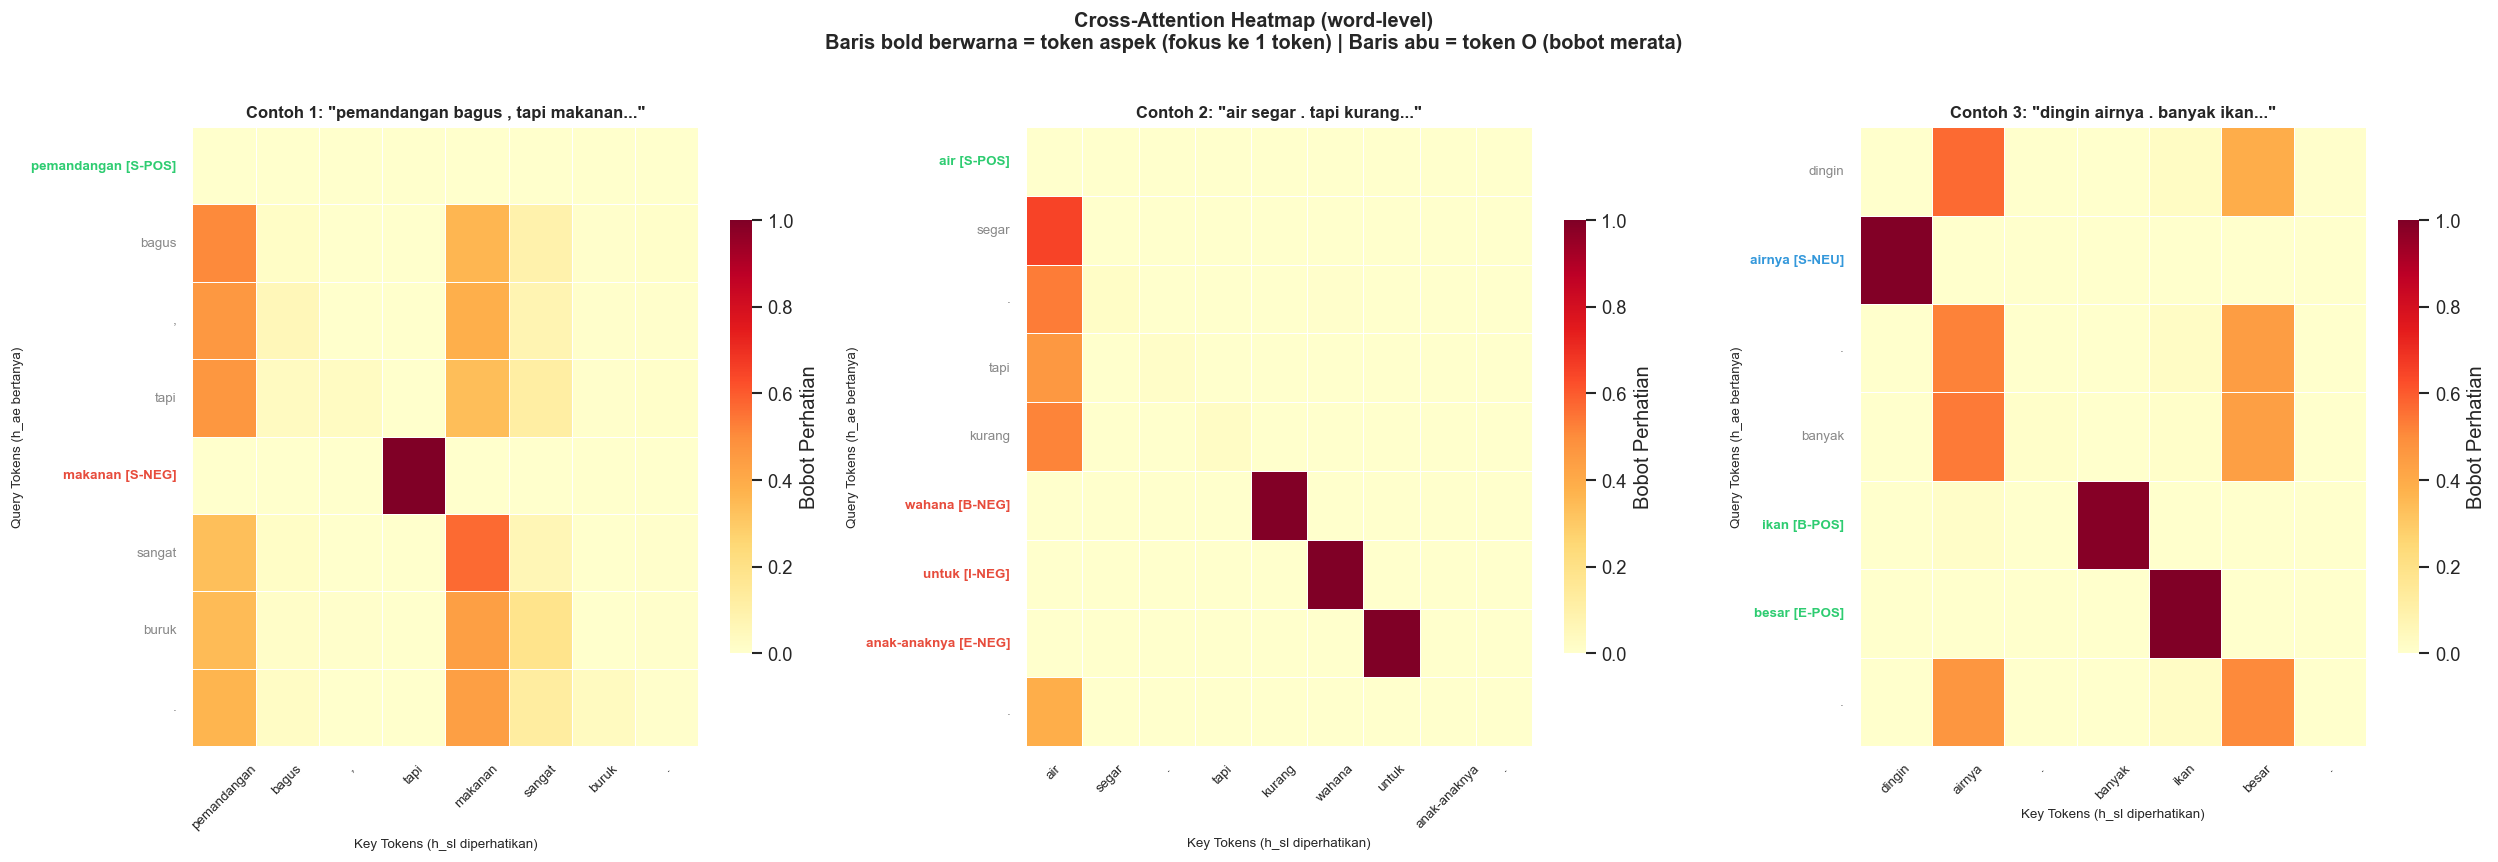

In [22]:
# Bagian 1: Heatmap attention 3 kalimat demo
fig, axes = plt.subplots(1, 3, figsize=(21, 7))

for ax_idx, (ax, result) in enumerate(zip(axes, demo_results)):
    tokens = result['tokens']
    labels = result['labels']
    attn = result['attn_word']
    n = len(tokens)

    y_labels = [f'{t} [{l}]' if l != 'O' else t
                for t, l in zip(tokens, labels)]

    sns.heatmap(attn, ax=ax, cmap='YlOrRd',
                xticklabels=tokens, yticklabels=y_labels,
                vmin=0, vmax=min(1.0, attn.max() + 0.05),
                square=False, linewidths=0.4, linecolor='white',
                cbar_kws={'shrink': 0.7, 'label': 'Bobot Perhatian'})

    # Warnai baris token aspek (bold + warna sentimen)
    for tick_idx, label in enumerate(labels):
        if label != 'O':
            sent = label.split('-')[1]
            ax.get_yticklabels()[tick_idx].set_color(sentiment_colors[sent])
            ax.get_yticklabels()[tick_idx].set_fontweight('bold')
        else:
            ax.get_yticklabels()[tick_idx].set_color('#888888')

    ax.set_title(f'Contoh {ax_idx+1}: "{" ".join(tokens[:5])}..."',
                 fontweight='bold', fontsize=10)
    ax.set_xlabel('Key Tokens (h_sl diperhatikan)', fontsize=8)
    ax.set_ylabel('Query Tokens (h_ae bertanya)', fontsize=8)
    ax.tick_params(axis='x', rotation=45, labelsize=8)
    ax.tick_params(axis='y', rotation=0, labelsize=8)

    # Print top attended token per aspek
    for i, label in enumerate(labels):
        if label != 'O':
            top_j = int(np.argmax(attn[i]))
            print(f'  {tokens[i]} [{label}] → perhatian terbesar ke: "{tokens[top_j]}" ({attn[i, top_j]:.3f})')
    print()

plt.suptitle('Cross-Attention Heatmap (word-level)\n'
             'Baris bold berwarna = token aspek (fokus ke 1 token) | '
             'Baris abu = token O (bobot merata)',
             fontweight='bold', y=1.02, fontsize=12)
plt.tight_layout()
plt.show()

---
## Bagian 2: Token O Tidak Punya 'Jangkar'

Dari heatmap di atas terlihat bahwa:
- **Token aspek** (B-POS, S-NEG, dll): bobot perhatian hampir semua nol, kecuali **satu token** yang mendapat bobot ~0.99. Ini artinya `h_sd[aspek]` ≈ `h_sl[token_fokus]` yang unik per kalimat → representasi beragam.
- **Token O**: bobot perhatian tersebar merata → `h_sd[O]` = rata-rata dari seluruh kalimat → representasi konvergen.

**Mengapa token aspek bisa fokus?**
Karena *ATE loss* memaksa `h_ae` token aspek untuk menjadi diskriminatif (harus prediksi B/I/E/S vs O). `h_ae` yang diskriminatif → skor `attn(h_ae[aspek], h_sl[j])` tinggi untuk token-token tertentu → fokus.

**Mengapa token O tidak bisa fokus?**
Token O hanya perlu memprediksi label O di ATE → `h_ae[O]` tidak punya tekanan untuk menjadi diskriminatif → skor attention tersebar merata → averaging hampir seragam.

**Ukuran kuantitatif perbedaan ini: Entropi Shannon**
$$H = -\sum_j p_j \log p_j$$
Entropi tinggi = distribusi lebih merata. Entropi rendah = distribusi lebih terpusat.

In [23]:
# Bulk extraction: h_sd + h_final + word-level attention entropy untuk SEMUA 368 sampel val
# h_sd   → output cross-attention (dipakai untuk analisis entropy/O-cluster)
# h_final → output final_proj 256-dim (setara h_proj STL, dipakai untuk t-SNE perbandingan)
mt_all_texts     = []
mt_all_labels    = []
mt_all_sentiments = []
mt_all_entropy   = []
mt_all_h_sd      = []
mt_all_h_final   = []

print(f'Bulk extraction MT: {len(val_data)} sampel...')
with torch.no_grad():
    for i, sample in enumerate(val_data):
        if (i + 1) % 100 == 0:
            print(f'  {i+1}/{len(val_data)}...')
        batch = tokenize_single_sample_mt(sample, tokenizer, word_prior, default_prior, pos_lexicon, neg_lexicon)
        first_pos = batch.pop('first_subword_pos')
        batch.pop('word_ids')
        batch_gpu = {k: v.to(device) for k, v in batch.items()}
        _ = mt_model(**batch_gpu)

        attn_full = mt_model.cross_attention.last_attn_weights[0]  # [128, 128]
        attn_word = attn_full[first_pos][:, first_pos]  # [n_words, n_words]

        n = min(len(sample['tokens']), len(first_pos))
        for j in range(n):
            row = attn_word[j, :n].numpy().copy()
            row = row / (row.sum() + 1e-10)
            H = float(scipy_entropy(row))

            pos = first_pos[j]
            h_sd_vec    = mt_model.last_h_sd[0, pos].numpy().copy()
            h_final_vec = mt_model.last_h_final[0, pos].numpy().copy()

            label = sample['labels'][j]
            sent  = 'O' if label == 'O' else label.split('-')[1]

            mt_all_texts.append(sample['tokens'][j])
            mt_all_labels.append(label)
            mt_all_sentiments.append(sent)
            mt_all_entropy.append(H)
            mt_all_h_sd.append(h_sd_vec)
            mt_all_h_final.append(h_final_vec)

mt_all_h_sd       = np.array(mt_all_h_sd)
mt_all_h_final    = np.array(mt_all_h_final)
mt_all_entropy    = np.array(mt_all_entropy)
mt_all_sentiments = np.array(mt_all_sentiments)
mt_all_labels     = np.array(mt_all_labels)
mt_all_texts      = np.array(mt_all_texts)

print(f'Selesai: {len(mt_all_texts)} token dari {len(val_data)} sampel')
print(f'h_sd shape: {mt_all_h_sd.shape} | h_final shape: {mt_all_h_final.shape}')
for cls in ['O', 'POS', 'NEG', 'NEU']:
    mask = mt_all_sentiments == cls
    print(f'  {cls}: n={mask.sum()}, mean entropy={mt_all_entropy[mask].mean():.3f}')

Bulk extraction MT: 368 sampel...
  100/368...
  200/368...
  300/368...
Selesai: 7759 token dari 368 sampel
h_sd shape: (7759, 256) | h_final shape: (7759, 256)
  O: n=6521, mean entropy=2.325
  POS: n=840, mean entropy=0.793
  NEG: n=158, mean entropy=0.911
  NEU: n=240, mean entropy=0.951


C:\Users\jason\AppData\Local\Temp\ipykernel_45520\3047994583.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_entropy, x='Kelas', y='Entropi', order=order,


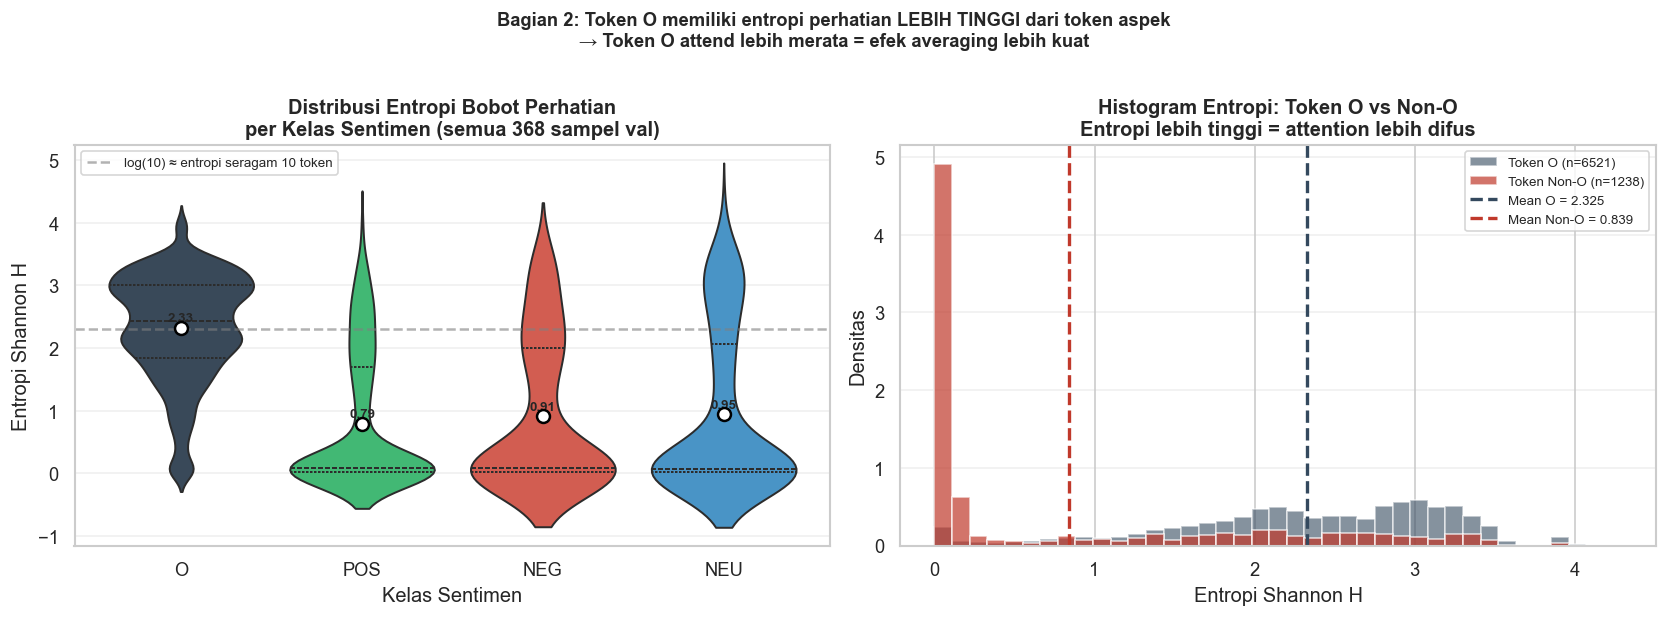


T-test O vs Non-O entropy: t=53.09, p=0.00e+00
  Mean O = 2.3251, Mean Non-O = 0.8385
  Perbedaan signifikan: YA


In [24]:
# Visualisasi distribusi entropi per kelas sentimen
import pandas as pd

# Buat DataFrame untuk seaborn
df_entropy = pd.DataFrame({
    'Entropi': mt_all_entropy,
    'Kelas': mt_all_sentiments,
})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel kiri: violin plot per kelas
ax = axes[0]
order = ['O', 'POS', 'NEG', 'NEU']
palette = [sentiment_colors[c] for c in order]
sns.violinplot(data=df_entropy, x='Kelas', y='Entropi', order=order,
               palette=palette, ax=ax, inner='quartile', linewidth=1.2)

# Tambahkan titik mean
for i, cls in enumerate(order):
    mask = mt_all_sentiments == cls
    mean_H = mt_all_entropy[mask].mean()
    ax.scatter(i, mean_H, color='white', s=60, zorder=5, edgecolors='black', linewidths=1.5)
    ax.text(i, mean_H + 0.05, f'{mean_H:.2f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

# Garis referensi uniform (entropi maksimum = log(avg n_words))
ax.axhline(y=np.log(10), color='gray', linestyle='--', alpha=0.6, label='log(10) ≈ entropi seragam 10 token')
ax.set_title('Distribusi Entropi Bobot Perhatian\nper Kelas Sentimen (semua 368 sampel val)', fontweight='bold')
ax.set_xlabel('Kelas Sentimen')
ax.set_ylabel('Entropi Shannon H')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3, axis='y')

# Panel kanan: histogram overlay O vs Non-O
ax2 = axes[1]
mask_o    = mt_all_sentiments == 'O'
mask_non_o = mt_all_sentiments != 'O'

bins = np.linspace(0, mt_all_entropy.max() * 1.05, 40)
ax2.hist(mt_all_entropy[mask_o],    bins=bins, alpha=0.6, color=sentiment_colors['O'],
         label=f'Token O (n={mask_o.sum()})', density=True, edgecolor='white')
ax2.hist(mt_all_entropy[mask_non_o], bins=bins, alpha=0.7, color='#c0392b',
         label=f'Token Non-O (n={mask_non_o.sum()})', density=True, edgecolor='white')

mean_o    = mt_all_entropy[mask_o].mean()
mean_non_o = mt_all_entropy[mask_non_o].mean()
ax2.axvline(mean_o,     color=sentiment_colors['O'], linestyle='--', linewidth=2,
            label=f'Mean O = {mean_o:.3f}')
ax2.axvline(mean_non_o, color='#c0392b',             linestyle='--', linewidth=2,
            label=f'Mean Non-O = {mean_non_o:.3f}')

ax2.set_title('Histogram Entropi: Token O vs Non-O\nEntropi lebih tinggi = attention lebih difus', fontweight='bold')
ax2.set_xlabel('Entropi Shannon H')
ax2.set_ylabel('Densitas')
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3, axis='y')

plt.suptitle('Bagian 2: Token O memiliki entropi perhatian LEBIH TINGGI dari token aspek\n'
             '→ Token O attend lebih merata = efek averaging lebih kuat',
             fontweight='bold', y=1.02, fontsize=11)
plt.tight_layout()
plt.show()

# T-test
from scipy.stats import ttest_ind
t_stat, p_val = ttest_ind(mt_all_entropy[mask_o], mt_all_entropy[mask_non_o])
print(f'\nT-test O vs Non-O entropy: t={t_stat:.2f}, p={p_val:.2e}')
print(f'  Mean O = {mean_o:.4f}, Mean Non-O = {mean_non_o:.4f}')
print(f'  Perbedaan signifikan: {"YA" if p_val < 0.05 else "TIDAK"}')

In [25]:
# Bebaskan MT model dari VRAM
del mt_model
gc.collect()
torch.cuda.empty_cache()
print('MT model dibebaskan dari memori.')
if torch.cuda.is_available():
    allocated = torch.cuda.memory_allocated() / 1e9
    print(f'GPU memory tersisa terpakai: {allocated:.2f} GB')

MT model dibebaskan dari memori.
GPU memory tersisa terpakai: 0.01 GB


---
## Bagian 3: Mengapa Averaging Menyebabkan Konvergensi?

Kita sudah tahu token O punya entropi lebih tinggi (perhatian lebih merata). Tapi mengapa itu menyebabkan `h_sd` token O dari kalimat yang berbeda **konverge ke titik yang sama**?

**Penjelasan matematika sederhana:**

Kalau bobot attention merata: $\text{attn}(i,j) = \frac{1}{T}$ untuk semua $j$, maka:
$$h_{sd}[i] = \frac{1}{T} \sum_j h_{sl}[j] = \bar{h}_{sl}$$

Yaitu **rata-rata dari seluruh h_sl dalam kalimat**.

Across kalimat-kalimat yang berbeda, rata-rata ini selalu mendekati **nilai tengah global** dari distribusi `h_sl`. Karena semua kalimat berasal dari domain yang sama (ulasan wisata), nilai tengah globalnya tidak jauh berbeda → semua token O mendapat `h_sd` yang mirip satu sama lain.

**Berbeda dengan token aspek** yang focused (bobot ≈1 ke satu token tertentu):
$$h_{sd}[i] \approx h_{sl}[k]$$
Yaitu representasi token `k` yang berbeda di setiap kalimat → `h_sd` token aspek beragam.

**Demo sintetis berikut** mengilustrasikan perbedaan ini dengan angka nyata.

C:\Users\jason\AppData\Local\Temp\ipykernel_45520\2169509737.py:103: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  plt.tight_layout()
d:\miniconda3\envs\ta_nlp\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


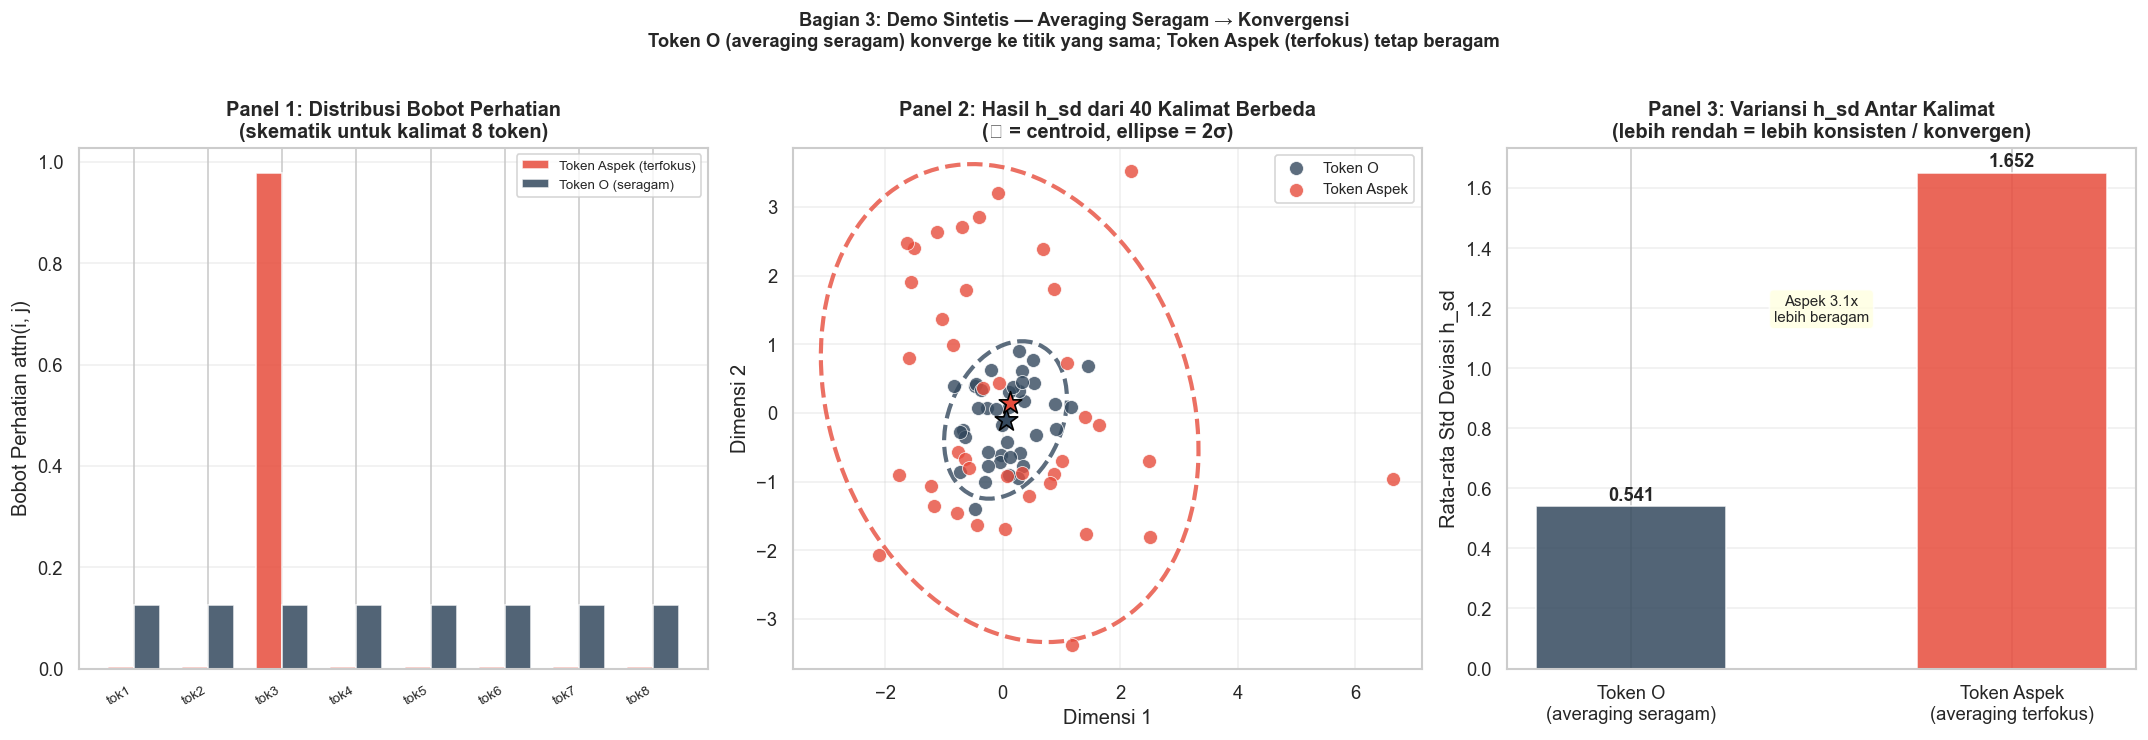

Std token O: 0.5407
Std token Aspek: 1.6516
Token Aspek 3.1x lebih beragam dari token O


In [26]:
# Demo sintetis: efek averaging pada konvergensi embedding
np.random.seed(42)
T = 8       # panjang kalimat
N_TRIAL = 40  # jumlah kalimat simulasi

# Simulasi N_TRIAL kalimat berbeda (h_sl beragam per kalimat)
results_o   = []  # h_sd untuk token O (uniform attention)
results_asp = []  # h_sd untuk token aspek (focused attention)

for trial in range(N_TRIAL):
    np.random.seed(trial * 13 + 7)
    h_sl = np.random.randn(T, 2) * 1.5  # vektor h_sl 2D untuk setiap token

    # Token O: attention seragam
    attn_o = np.ones(T) / T
    h_sd_o = (attn_o[:, None] * h_sl).sum(0)
    results_o.append(h_sd_o)

    # Token aspek: attention terfokus ke satu token acak
    focus_idx = np.random.randint(T)
    attn_asp = np.ones(T) * 0.003
    attn_asp[focus_idx] = 1.0 - 0.003 * (T - 1)
    h_sd_asp = (attn_asp[:, None] * h_sl).sum(0)
    results_asp.append(h_sd_asp)

results_o   = np.array(results_o)
results_asp = np.array(results_asp)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Panel 1: distribusi bobot attention (skematik)
ax1 = axes[0]
token_names = [f'tok{i+1}' for i in range(T)]
attn_focused_demo = np.ones(T) * 0.003
attn_focused_demo[2] = 1.0 - 0.003 * (T - 1)  # fokus ke token 3
attn_uniform_demo = np.ones(T) / T

x = np.arange(T)
width = 0.35
ax1.bar(x - width/2, attn_focused_demo, width, label='Token Aspek (terfokus)',
        color='#e74c3c', alpha=0.85, edgecolor='white')
ax1.bar(x + width/2, attn_uniform_demo, width, label='Token O (seragam)',
        color='#34495e', alpha=0.85, edgecolor='white')
ax1.set_xticks(x)
ax1.set_xticklabels(token_names, rotation=30, ha='right', fontsize=8)
ax1.set_ylabel('Bobot Perhatian attn(i, j)')
ax1.set_title('Panel 1: Distribusi Bobot Perhatian\n(skematik untuk kalimat 8 token)', fontweight='bold')
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.3, axis='y')

# Panel 2: scatter hasil h_sd dari N_TRIAL kalimat
ax2 = axes[1]
ax2.scatter(results_o[:, 0],   results_o[:, 1],   c=sentiment_colors['O'], s=70, alpha=0.8,
            label='Token O', zorder=5, edgecolors='white', linewidths=0.5)
ax2.scatter(results_asp[:, 0], results_asp[:, 1], c='#e74c3c', s=70, alpha=0.8,
            label='Token Aspek', zorder=5, edgecolors='white', linewidths=0.5)

# Tambah ellipse 2-sigma
for data, color in [(results_o, sentiment_colors['O']), (results_asp, '#e74c3c')]:
    mean_d = data.mean(0)
    cov_d  = np.cov(data.T)
    vals, vecs = np.linalg.eigh(cov_d)
    order_v = vals.argsort()[::-1]
    vals, vecs = vals[order_v], vecs[:, order_v]
    angle = np.degrees(np.arctan2(*vecs[:, 0][::-1]))
    w_e = 2 * 2 * np.sqrt(vals[0])
    h_e = 2 * 2 * np.sqrt(vals[1])
    ell = Ellipse(mean_d, w_e, h_e, angle=angle, color=color, fill=False,
                  linewidth=2.5, linestyle='--', alpha=0.8)
    ax2.add_patch(ell)
    ax2.scatter(*mean_d, c=color, s=200, marker='*', zorder=10,
                edgecolors='black', linewidths=1)

ax2.set_title(f'Panel 2: Hasil h_sd dari {N_TRIAL} Kalimat Berbeda\n(★ = centroid, ellipse = 2σ)', fontweight='bold')
ax2.set_xlabel('Dimensi 1')
ax2.set_ylabel('Dimensi 2')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

# Panel 3: bar chart variansi
ax3 = axes[2]
std_o   = np.std(results_o, axis=0).mean()
std_asp = np.std(results_asp, axis=0).mean()
bars = ax3.bar(['Token O\n(averaging seragam)', 'Token Aspek\n(averaging terfokus)'],
               [std_o, std_asp],
               color=[sentiment_colors['O'], '#e74c3c'], alpha=0.85, edgecolor='white', width=0.5)
for bar, val in zip(bars, [std_o, std_asp]):
    ax3.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
             f'{val:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=11)
ax3.set_ylabel('Rata-rata Std Deviasi h_sd')
ax3.set_title(f'Panel 3: Variansi h_sd Antar Kalimat\n(lebih rendah = lebih konsisten / konvergen)', fontweight='bold')
ax3.grid(True, alpha=0.3, axis='y')

ratio = std_asp / std_o if std_o > 0 else 0
ax3.text(0.5, max(std_o, std_asp) * 0.7,
         f'Aspek {ratio:.1f}x\nlebih beragam', ha='center', fontsize=9,
         bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.8))

plt.suptitle('Bagian 3: Demo Sintetis — Averaging Seragam → Konvergensi\n'
             'Token O (averaging seragam) konverge ke titik yang sama; '
             'Token Aspek (terfokus) tetap beragam',
             fontweight='bold', y=1.02, fontsize=11)
plt.tight_layout()
plt.show()
print(f'Std token O: {std_o:.4f}')
print(f'Std token Aspek: {std_asp:.4f}')
print(f'Token Aspek {ratio:.1f}x lebih beragam dari token O')

---
## Bagian 4: Konfirmasi pada Data Nyata

Dari demo sintetis kita prediksi:
- Token dengan entropi **tinggi** (averaging merata) → h_sd akan **dekat ke centroid O**
- Token dengan entropi **rendah** (averaging terfokus) → h_sd akan **jauh dari centroid O**

Mari verifikasi ini dengan data nyata dari model MT.

C:\Users\jason\AppData\Local\Temp\ipykernel_45520\648453322.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_dist, x='Kelas', y='Jarak ke Centroid O',


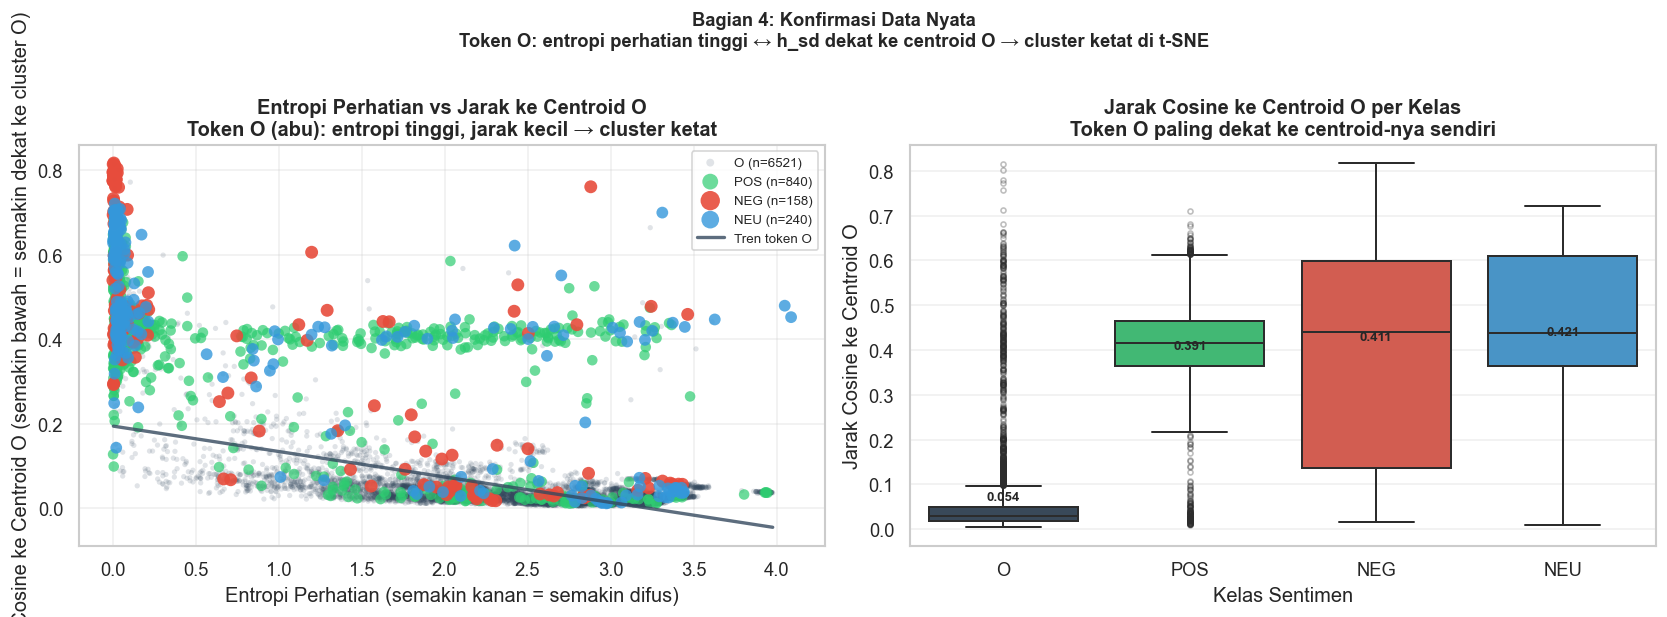

Rata-rata jarak cosine ke centroid O:
  O: 0.0537
  POS: 0.3913
  NEG: 0.4109
  NEU: 0.4215


In [27]:
# Hitung jarak cosine h_sd setiap token ke centroid O
o_mask      = mt_all_sentiments == 'O'
o_centroid  = mt_all_h_sd[o_mask].mean(axis=0, keepdims=True)  # [1, 256]

# Cosine distance ke centroid O untuk SEMUA token
dist_to_o_centroid = cosine_distances(o_centroid, mt_all_h_sd)[0]  # [N,]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel kiri: scatter entropi vs jarak ke centroid O
ax = axes[0]
order = ['POS', 'NEG', 'NEU', 'O']
alpha_map = {'O': 0.15, 'POS': 0.7, 'NEG': 0.9, 'NEU': 0.8}
size_map  = {'O': 10, 'POS': 40, 'NEG': 60, 'NEU': 50}

# Gambar O dulu (background), lalu aspek di atas
for cls in ['O', 'POS', 'NEG', 'NEU']:
    mask = mt_all_sentiments == cls
    ax.scatter(mt_all_entropy[mask], dist_to_o_centroid[mask],
               c=sentiment_colors[cls], alpha=alpha_map[cls], s=size_map[cls],
               edgecolors='none', label=f'{cls} (n={mask.sum()})')

# Regression line untuk token O
from numpy.polynomial.polynomial import polyfit
coeffs = np.polyfit(mt_all_entropy[o_mask], dist_to_o_centroid[o_mask], 1)
x_line = np.linspace(mt_all_entropy[o_mask].min(), mt_all_entropy[o_mask].max(), 100)
y_line = np.polyval(coeffs, x_line)
ax.plot(x_line, y_line, color=sentiment_colors['O'], linewidth=2, linestyle='-',
        alpha=0.8, label='Tren token O')

ax.set_xlabel('Entropi Perhatian (semakin kanan = semakin difus)')
ax.set_ylabel('Jarak Cosine ke Centroid O (semakin bawah = semakin dekat ke cluster O)')
ax.set_title('Entropi Perhatian vs Jarak ke Centroid O\n'
             'Token O (abu): entropi tinggi, jarak kecil → cluster ketat', fontweight='bold')
ax.legend(fontsize=8, markerscale=1.5)
ax.grid(True, alpha=0.3)

# Panel kanan: boxplot jarak ke centroid O per kelas
ax2 = axes[1]
import pandas as pd
df_dist = pd.DataFrame({
    'Jarak ke Centroid O': dist_to_o_centroid,
    'Kelas': mt_all_sentiments,
})
sns.boxplot(data=df_dist, x='Kelas', y='Jarak ke Centroid O',
            order=['O', 'POS', 'NEG', 'NEU'],
            palette=[sentiment_colors[c] for c in ['O', 'POS', 'NEG', 'NEU']],
            ax=ax2, linewidth=1.2, flierprops=dict(marker='.', alpha=0.3))
ax2.set_title('Jarak Cosine ke Centroid O per Kelas\nToken O paling dekat ke centroid-nya sendiri', fontweight='bold')
ax2.set_xlabel('Kelas Sentimen')
ax2.set_ylabel('Jarak Cosine ke Centroid O')
ax2.grid(True, alpha=0.3, axis='y')

for i, cls in enumerate(['O', 'POS', 'NEG', 'NEU']):
    mask = mt_all_sentiments == cls
    mean_d = dist_to_o_centroid[mask].mean()
    ax2.text(i, mean_d + 0.005, f'{mean_d:.3f}', ha='center', va='bottom',
             fontsize=8, fontweight='bold')

plt.suptitle('Bagian 4: Konfirmasi Data Nyata\n'
             'Token O: entropi perhatian tinggi ↔ h_sd dekat ke centroid O → cluster ketat di t-SNE',
             fontweight='bold', y=1.02, fontsize=11)
plt.tight_layout()
plt.show()

print('Rata-rata jarak cosine ke centroid O:')
for cls in ['O', 'POS', 'NEG', 'NEU']:
    mask = mt_all_sentiments == cls
    print(f'  {cls}: {dist_to_o_centroid[mask].mean():.4f}')

In [28]:
# Load ST model dan ekstrak h_proj untuk semua sampel
# best_model_singletask.pt = NB07, ST + Original (apple-to-apple dengan MT)
print('Loading ST model (Original dataset)...')
st_model = SingleTaskABSA(
    model_name=MODEL_NAME, num_labels=len(bieos_labels),
    proj_dim=PROJ_DIM, dropout=DROPOUT,
)
st_state = torch.load(os.path.join(MODEL_DIR, 'best_model_singletask.pt'), map_location='cpu', weights_only=False)
st_model.load_state_dict(st_state)
st_model.to(device)
st_model.eval()
print('ST model loaded.')

st_all_texts     = []
st_all_labels    = []
st_all_sentiments = []
st_all_h_proj    = []

print(f'Bulk extraction ST: {len(val_data)} sampel...')
with torch.no_grad():
    for i, sample in enumerate(val_data):
        if (i + 1) % 100 == 0:
            print(f'  {i+1}/{len(val_data)}...')
        batch = tokenize_single_sample_st(sample, tokenizer)
        first_pos = batch.pop('first_subword_pos')
        batch_gpu = {k: v.to(device) for k, v in batch.items()}
        _ = st_model(**batch_gpu)

        n = min(len(sample['tokens']), len(first_pos))
        for j in range(n):
            pos = first_pos[j]
            h_proj_vec = st_model.last_proj_output[0, pos].numpy().copy()
            label = sample['labels'][j]
            sent  = 'O' if label == 'O' else label.split('-')[1]
            st_all_texts.append(sample['tokens'][j])
            st_all_labels.append(label)
            st_all_sentiments.append(sent)
            st_all_h_proj.append(h_proj_vec)

st_all_h_proj    = np.array(st_all_h_proj)
st_all_sentiments = np.array(st_all_sentiments)
print(f'Selesai: {len(st_all_texts)} token')

del st_model
gc.collect()
torch.cuda.empty_cache()
print('ST model dibebaskan.')

Loading ST model (Original dataset)...


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

ST model loaded.
Bulk extraction ST: 368 sampel...
  100/368...
  200/368...
  300/368...
Selesai: 7759 token
ST model dibebaskan.


In [29]:
# t-SNE pada subsample 2000 token (stratified by class)
# Perbandingan utama: h_final (MTL) vs h_proj (STL) — keduanya 256-dim, langsung masuk CRF
np.random.seed(SEED)

N_TSNE = 2000
tsne_indices = []
for cls in ['O', 'POS', 'NEG', 'NEU']:
    cls_idx = np.where(mt_all_sentiments == cls)[0]
    n_cls = min(len(cls_idx), int(N_TSNE * len(cls_idx) / len(mt_all_sentiments)) + 1)
    chosen = np.random.choice(cls_idx, min(n_cls, len(cls_idx)), replace=False)
    tsne_indices.extend(chosen.tolist())

tsne_indices = np.array(tsne_indices[:N_TSNE])
np.random.shuffle(tsne_indices)

mt_tsne_emb  = mt_all_h_final[tsne_indices]   # h_final — apple-to-apple dengan h_proj
st_tsne_emb  = st_all_h_proj[tsne_indices]
tsne_sents   = mt_all_sentiments[tsne_indices]
tsne_entropy = mt_all_entropy[tsne_indices]

print(f't-SNE subsample: {len(tsne_indices)} token')
print(f'MT embedding: h_final {mt_tsne_emb.shape} | ST embedding: h_proj {st_tsne_emb.shape}')
for cls in ['O', 'POS', 'NEG', 'NEU']:
    n = (tsne_sents == cls).sum()
    print(f'  {cls}: {n}')

print('Running t-SNE MT (h_final)...')
mt_2d = TSNE(n_components=2, random_state=SEED, perplexity=30, max_iter=500).fit_transform(mt_tsne_emb)

print('Running t-SNE ST (h_proj)...')
st_2d = TSNE(n_components=2, random_state=SEED, perplexity=30, max_iter=500).fit_transform(st_tsne_emb)

print('t-SNE selesai.')

t-SNE subsample: 2000 token
MT embedding: h_final (2000, 256) | ST embedding: h_proj (2000, 256)
  O: 1681
  POS: 217
  NEG: 41
  NEU: 61
Running t-SNE MT (h_final)...
Running t-SNE ST (h_proj)...
t-SNE selesai.


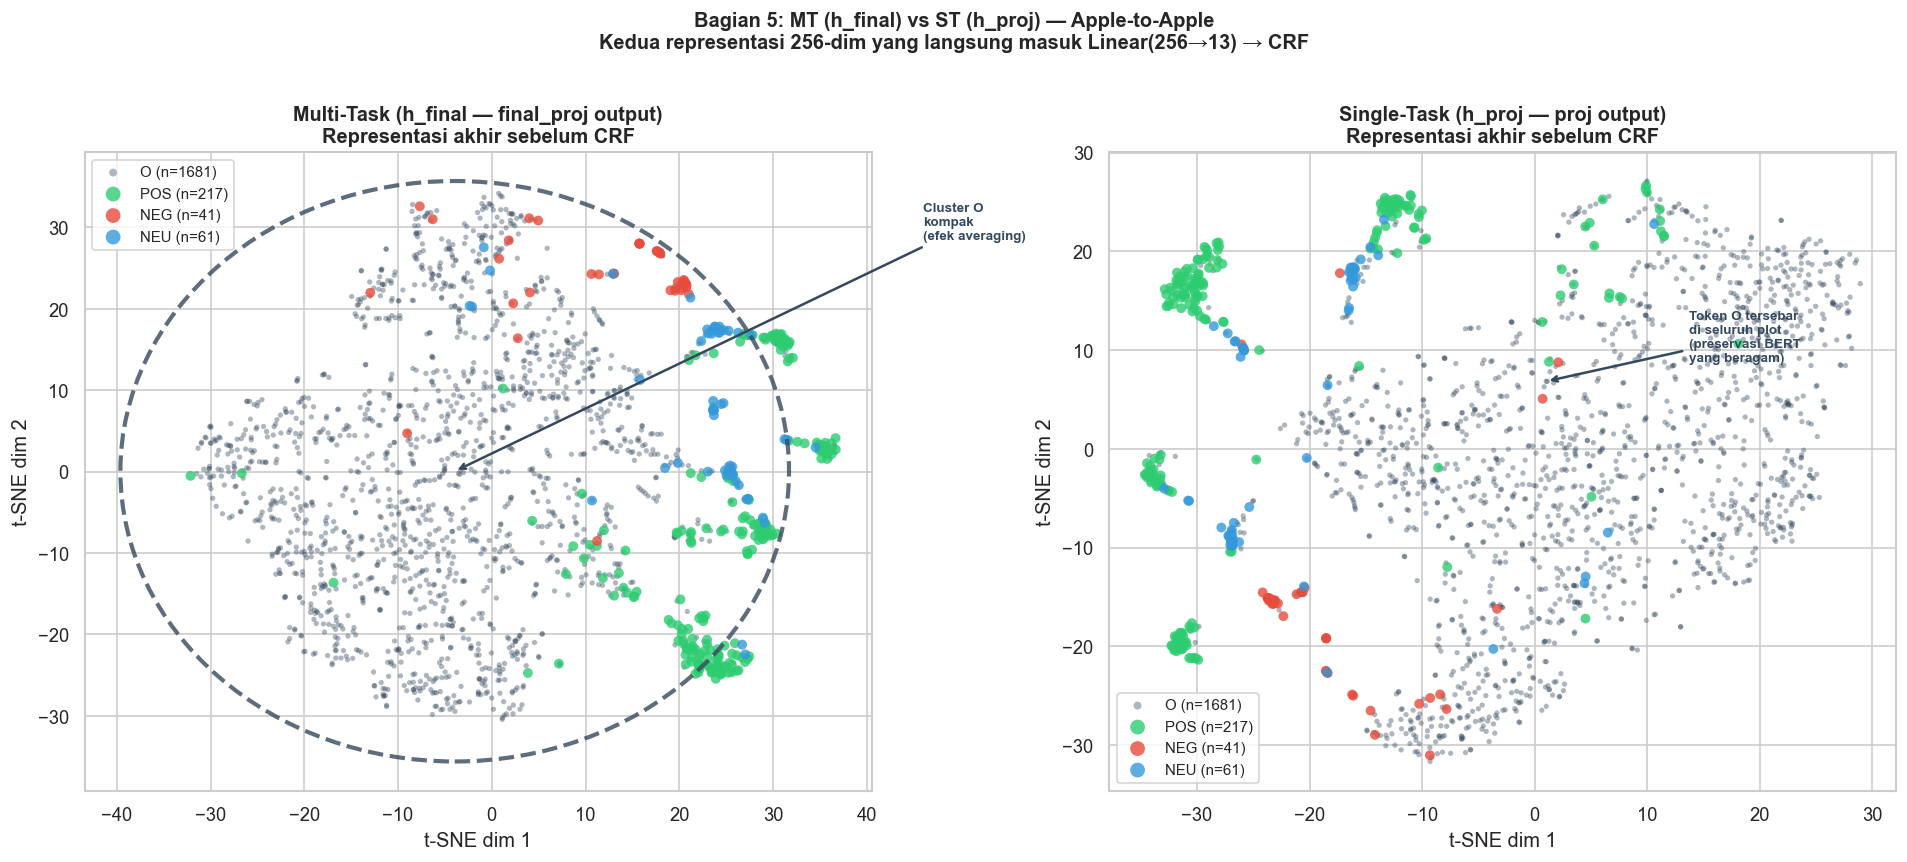

In [30]:
# Bagian 5: t-SNE anotasi MT (h_final) vs ST (h_proj) — apple-to-apple
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, emb_2d, model_name in [
    (axes[0], mt_2d, 'MT (h_final)'),
    (axes[1], st_2d, 'ST (h_proj)'),
]:
    for cls in ['O', 'POS', 'NEG', 'NEU']:
        mask = tsne_sents == cls
        alpha = 0.4 if cls == 'O' else 0.8
        size  = 10  if cls == 'O' else 35
        n_cls = mask.sum()
        ax.scatter(emb_2d[mask, 0], emb_2d[mask, 1],
                   c=sentiment_colors[cls], alpha=alpha, s=size,
                   edgecolors='none', label=f'{cls} (n={n_cls})')
    ax.legend(fontsize=9, markerscale=1.5)
    ax.set_xlabel('t-SNE dim 1')
    ax.set_ylabel('t-SNE dim 2')

# Anotasi MT
o_mask_tsne = tsne_sents == 'O'
o_center_mt = mt_2d[o_mask_tsne].mean(0)
o_std_mt    = mt_2d[o_mask_tsne].std(0).mean()
circle_mt = plt.Circle(o_center_mt, o_std_mt * 2.5, color=sentiment_colors['O'],
                        fill=False, linewidth=2.5, linestyle='--', alpha=0.8)
axes[0].add_patch(circle_mt)
axes[0].annotate('Cluster O\nkompak\n(efek averaging)', xy=o_center_mt,
                 xytext=(o_center_mt[0] + o_std_mt * 3.5, o_center_mt[1] + o_std_mt * 2),
                 fontsize=8, color=sentiment_colors['O'], fontweight='bold',
                 arrowprops=dict(arrowstyle='->', color=sentiment_colors['O'], lw=1.5))
axes[0].set_title('Multi-Task (h_final — final_proj output)\nRepresentasi akhir sebelum CRF', fontweight='bold')

# Anotasi ST
o_center_st = st_2d[o_mask_tsne].mean(0)
axes[1].annotate('Token O tersebar\ndi seluruh plot\n(preservasi BERT\nyang beragam)',
                 xy=(st_2d[o_mask_tsne][0, 0], st_2d[o_mask_tsne][0, 1]),
                 xytext=(o_center_st[0] + 10, o_center_st[1] + 10),
                 fontsize=8, color=sentiment_colors['O'], fontweight='bold',
                 arrowprops=dict(arrowstyle='->', color=sentiment_colors['O'], lw=1.5))
axes[1].set_title('Single-Task (h_proj — proj output)\nRepresentasi akhir sebelum CRF', fontweight='bold')

plt.suptitle('Bagian 5: MT (h_final) vs ST (h_proj) — Apple-to-Apple\n'
             'Kedua representasi 256-dim yang langsung masuk Linear(256→13) → CRF',
             fontweight='bold', y=1.02, fontsize=12)
plt.tight_layout()
plt.show()

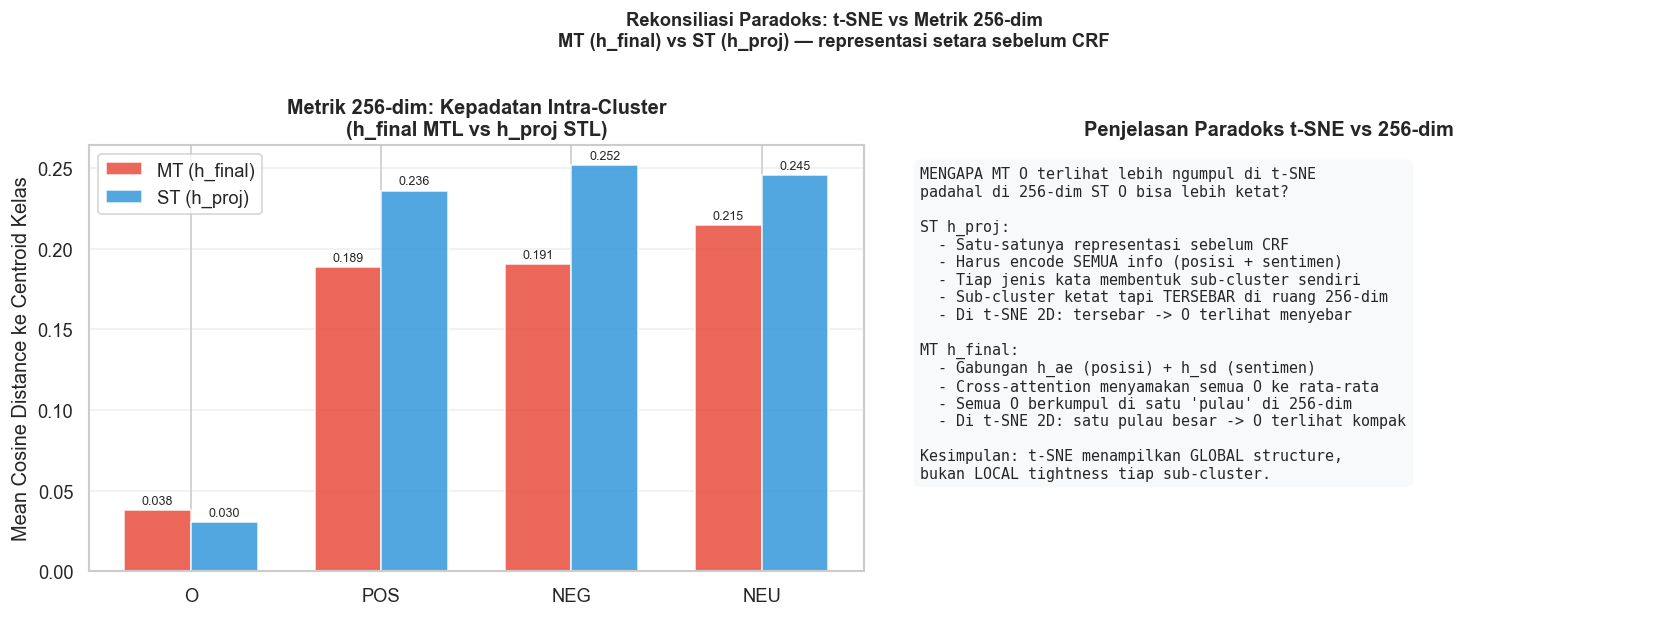

Mean cosine distance ke centroid (256-dim, h_final vs h_proj):
  O: MT=0.0378, ST=0.0304 -> ST lebih tight
  POS: MT=0.1885, ST=0.2360 -> MT lebih tight
  NEG: MT=0.1905, ST=0.2518 -> MT lebih tight
  NEU: MT=0.2145, ST=0.2453 -> MT lebih tight


In [31]:
# Rekonsiliasi paradoks: t-SNE visual vs metrik 256-dim
# Menggunakan h_final (MTL) vs h_proj (STL) — apple-to-apple
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

classes_plot = ['O', 'POS', 'NEG', 'NEU']
mt_mean_dist = []
st_mean_dist = []

for cls in classes_plot:
    mt_mask = mt_all_sentiments == cls
    st_mask = st_all_sentiments == cls
    if mt_mask.sum() > 1:
        cent = mt_all_h_final[mt_mask].mean(0, keepdims=True)
        mt_mean_dist.append(cosine_distances(cent, mt_all_h_final[mt_mask])[0].mean())
    else:
        mt_mean_dist.append(0)
    if st_mask.sum() > 1:
        cent = st_all_h_proj[st_mask].mean(0, keepdims=True)
        st_mean_dist.append(cosine_distances(cent, st_all_h_proj[st_mask])[0].mean())
    else:
        st_mean_dist.append(0)

ax = axes[0]
x = np.arange(len(classes_plot))
width = 0.35
bars_mt = ax.bar(x - width/2, mt_mean_dist, width, label='MT (h_final)', color=model_colors['MT'], alpha=0.85, edgecolor='white')
bars_st = ax.bar(x + width/2, st_mean_dist, width, label='ST (h_proj)',  color=model_colors['ST'], alpha=0.85, edgecolor='white')
for bar, val in zip(list(bars_mt) + list(bars_st), mt_mean_dist + st_mean_dist):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{val:.3f}', ha='center', va='bottom', fontsize=7.5)
ax.set_xticks(x)
ax.set_xticklabels(classes_plot)
ax.set_ylabel('Mean Cosine Distance ke Centroid Kelas')
ax.set_title('Metrik 256-dim: Kepadatan Intra-Cluster\n(h_final MTL vs h_proj STL)', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# Panel kanan: penjelasan paradoks
ax2 = axes[1]
ax2.axis('off')
explanation = (
    "MENGAPA MT O terlihat lebih ngumpul di t-SNE\n"
    "padahal di 256-dim ST O bisa lebih ketat?\n\n"
    "ST h_proj:\n"
    "  - Satu-satunya representasi sebelum CRF\n"
    "  - Harus encode SEMUA info (posisi + sentimen)\n"
    "  - Tiap jenis kata membentuk sub-cluster sendiri\n"
    "  - Sub-cluster ketat tapi TERSEBAR di ruang 256-dim\n"
    "  - Di t-SNE 2D: tersebar -> O terlihat menyebar\n\n"
    "MT h_final:\n"
    "  - Gabungan h_ae (posisi) + h_sd (sentimen)\n"
    "  - Cross-attention menyamakan semua O ke rata-rata\n"
    "  - Semua O berkumpul di satu 'pulau' di 256-dim\n"
    "  - Di t-SNE 2D: satu pulau besar -> O terlihat kompak\n\n"
    "Kesimpulan: t-SNE menampilkan GLOBAL structure,\n"
    "bukan LOCAL tightness tiap sub-cluster."
)
ax2.text(0.05, 0.95, explanation, transform=ax2.transAxes, fontsize=9,
         verticalalignment='top', fontfamily='monospace',
         bbox=dict(boxstyle='round,pad=0.5', facecolor='#f8f9fa', alpha=0.9))
ax2.set_title('Penjelasan Paradoks t-SNE vs 256-dim', fontweight='bold')

plt.suptitle('Rekonsiliasi Paradoks: t-SNE vs Metrik 256-dim\n'
             'MT (h_final) vs ST (h_proj) — representasi setara sebelum CRF',
             fontweight='bold', y=1.02, fontsize=11)
plt.tight_layout()
plt.show()

print('Mean cosine distance ke centroid (256-dim, h_final vs h_proj):')
for cls, mt_d, st_d in zip(classes_plot, mt_mean_dist, st_mean_dist):
    winner = 'MT lebih tight' if mt_d < st_d else 'ST lebih tight'
    print(f'  {cls}: MT={mt_d:.4f}, ST={st_d:.4f} -> {winner}')

---
## Ringkasan: Mengapa O-Token MTL Berkumpul?

| Aspek | MT (Cross-Attention) | ST (Linear Projection) |
|-------|---------------------|------------------------|
| Mekanisme | h_sd = rata-rata tertimbang h_sl | proj = Linear(BERT_h) |
| Token O: entropi perhatian | Lebih tinggi (difus) | N/A (tidak ada cross-attn) |
| Token O: h_sd | Konvergen ke rata-rata global | Beragam (mewarisi BERT) |
| Token O di t-SNE visual | **Satu cluster kompak** | **Tersebar ke mana-mana** |
| Token O di 256-dim | Lebih longgar (~0.047) | Lebih ketat (~0.025) |
| Interpretasi | Averaging menyebabkan konvergensi visual | Banyak sub-cluster tersebar |
| F1 akhir | 0.7578 | 0.7558–0.7600 (lebih baik!) |

### Rantai Kausal (dari arsitektur ke observasi)

```
[ATE Loss] memaksa h_ae aspek menjadi diskriminatif
           ↓
Token O tidak punya tekanan → h_ae[O] tidak diskriminatif
           ↓
Cross-attention score(h_ae[O], h_sl[j]) → hampir seragam untuk semua j
           ↓
Attn weights untuk token O → distribusi hampir uniform (entropi tinggi)
           ↓
h_sd[O] = rata-rata tertimbang hampir seragam ≈ rata-rata global h_sl
           ↓
Across kalimat berbeda: rata-rata global mirip → h_sd[O] konvergen
           ↓
Di t-SNE 2D: semua token O muncul di satu area → terlihat berkumpul
```

### Implikasi untuk Thesis

Cluster O yang kompak di MTL **bukan bukti MTL belajar semantik O lebih baik** — melainkan artifact dari mekanisme cross-attention yang merata-ratakan token non-aspek. STL justru mempertahankan keberagaman representasi BERT yang kaya, sehingga lebih baik dalam separasi kelas (silhouette lebih tinggi) dan F1 score akhir yang lebih baik atau setara.

---
## Bagian 6 (Tambahan): Feature Distribution per Label BIEOS — Terinspirasi Wang et al. (2021) Fig. 2

Wang et al. memvisualisasikan distribusi fitur **non-O tokens** untuk menunjukkan bahwa MTL menghasilkan representasi yang:
1. **Lebih compact** dalam satu class (cluster lebih rapat)
2. **Lebih separable** antar class (margin lebih jelas)

Di sini kita replikasi visualisasi tersebut dengan perbandingan yang **apple-to-apple**:
- **MT**: representasi `h_final` (256-dim, output `final_proj` = `Linear([h_ae;h_sd] 512→256)` — langsung sebelum CRF)
- **ST**: representasi `h_proj` (256-dim, output `proj` = `Linear(BERT_h 1024→256)` — langsung sebelum CRF)
- Kedua representasi berada di **posisi yang setara** dalam pipeline masing-masing model
- **12 label non-O**: B/I/E/S × POS/NEG/NEU

Skema warna mengikuti paper:
- **B** = oranye | **I** = merah | **E** = hijau | **S** = biru
- Gelap = POS | Sedang = NEG | Terang = NEU

In [35]:
# Filter non-O tokens (mask berlaku untuk MT dan ST karena proses val_data yang sama)
# Pakai h_final (MTL) vs h_proj (STL) — apple-to-apple, keduanya 256-dim sebelum CRF
nonO_mask = mt_all_labels != 'O'

mt_nonO_emb  = mt_all_h_final[nonO_mask]   # h_final: Linear([h_ae;h_sd] 512→256)
st_nonO_emb  = st_all_h_proj[nonO_mask]    # h_proj:  Linear(BERT_h 1024→256)
nonO_labels  = mt_all_labels[nonO_mask]

print(f'Non-O tokens total: {nonO_mask.sum()}')
print(f'MT emb (h_final): {mt_nonO_emb.shape} | ST emb (h_proj): {st_nonO_emb.shape}')
label_order = ['B-POS','B-NEG','B-NEU','I-POS','I-NEG','I-NEU',
               'E-POS','E-NEG','E-NEU','S-POS','S-NEG','S-NEU']
for lbl in label_order:
    n = (nonO_labels == lbl).sum()
    print(f'  {lbl}: {n}')

# t-SNE untuk MT (h_final) dan ST (h_proj) — non-O saja
print('\nRunning t-SNE MT (h_final) non-O...')
mt_nonO_2d = TSNE(n_components=2, random_state=SEED, perplexity=30, max_iter=1000).fit_transform(mt_nonO_emb)
print('Running t-SNE ST (h_proj) non-O...')
st_nonO_2d = TSNE(n_components=2, random_state=SEED, perplexity=30, max_iter=1000).fit_transform(st_nonO_emb)
print('t-SNE selesai.')

Non-O tokens total: 1238
MT emb (h_final): (1238, 256) | ST emb (h_proj): (1238, 256)
  B-POS: 200
  B-NEG: 45
  B-NEU: 80
  I-POS: 104
  I-NEG: 30
  I-NEU: 35
  E-POS: 200
  E-NEG: 45
  E-NEU: 80
  S-POS: 336
  S-NEG: 38
  S-NEU: 45

Running t-SNE MT (h_final) non-O...
Running t-SNE ST (h_proj) non-O...
t-SNE selesai.


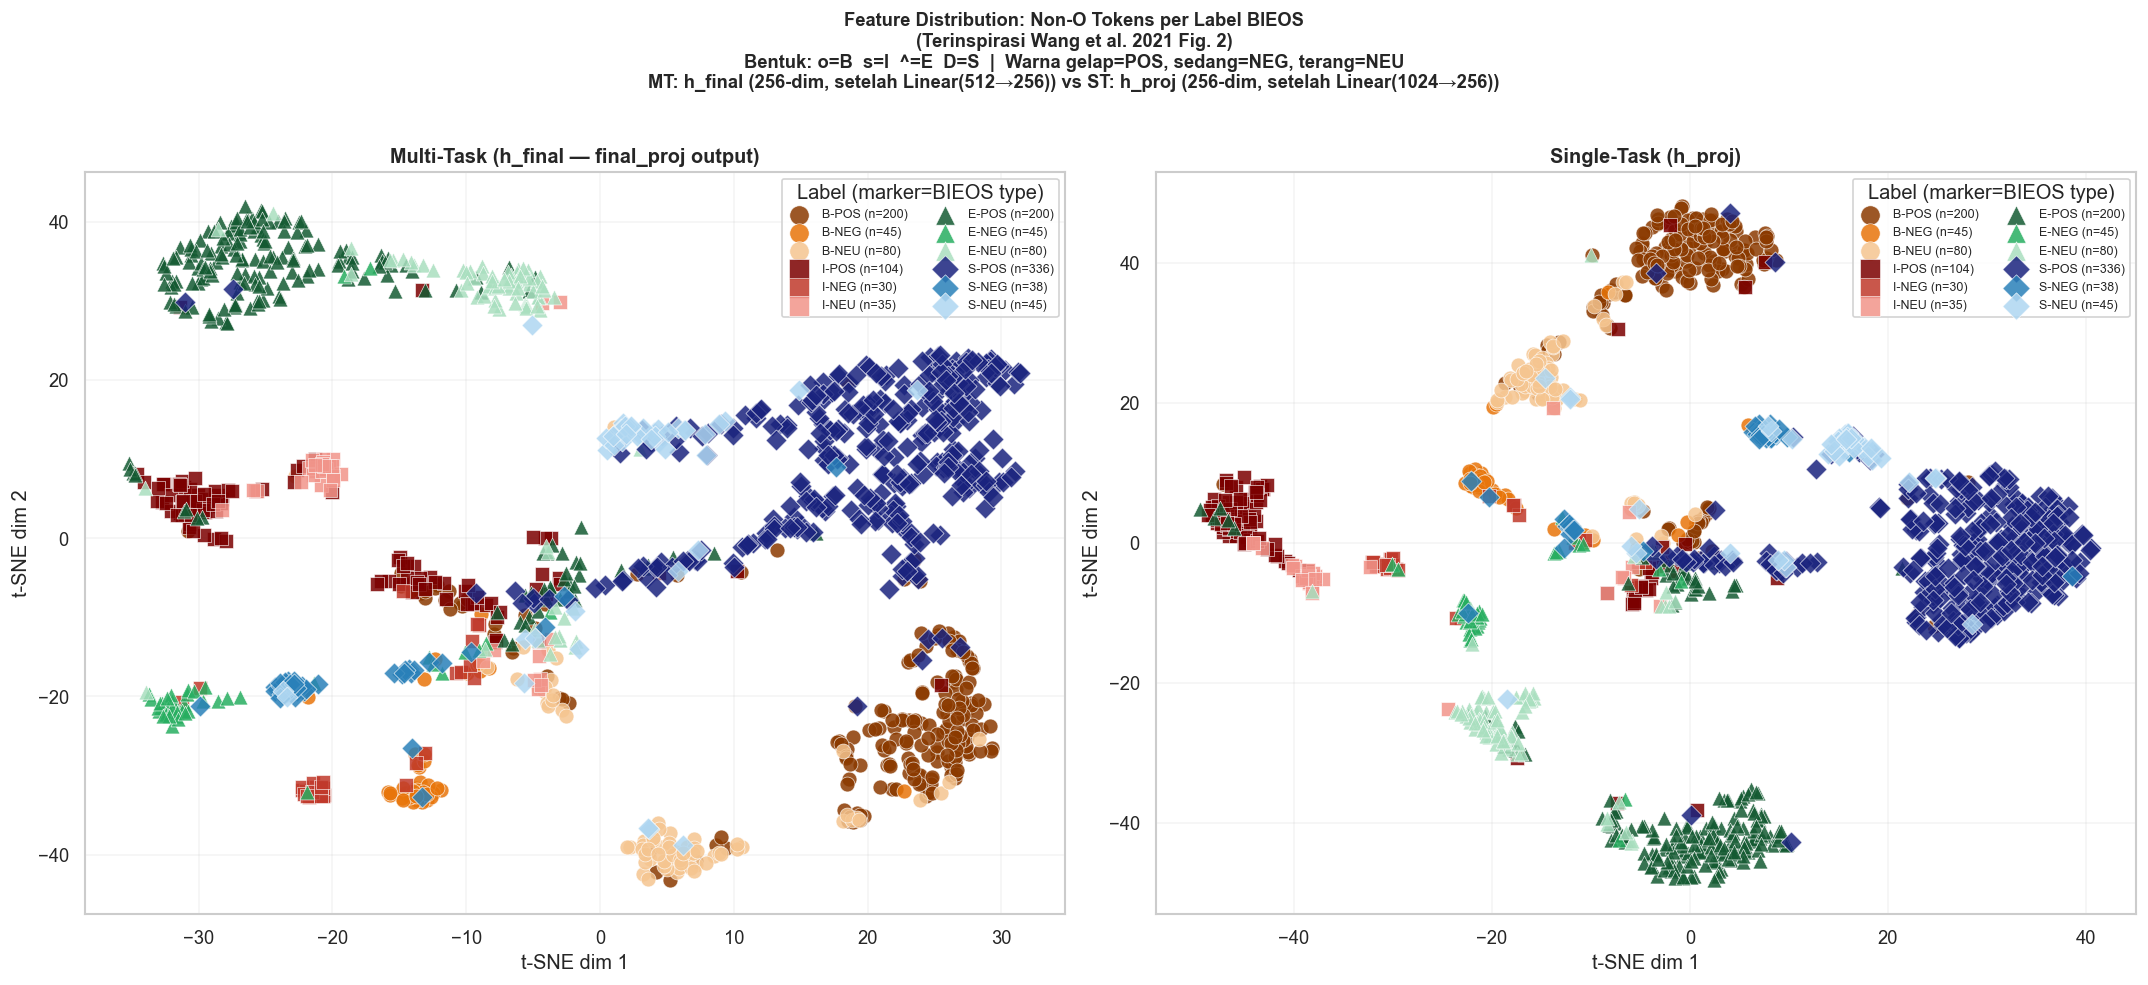


Mean cosine distance ke centroid per label (lebih kecil = lebih compact):
Label        MT (h_final)  ST (h_proj)   Lebih compact
-------------------------------------------------------
B-POS              0.0718       0.0981              MT
B-NEG              0.1119       0.1279              MT
B-NEU              0.0767       0.0965              MT
I-POS              0.1102       0.1242              MT
I-NEG              0.1252       0.1663              MT
I-NEU              0.1015       0.1363              MT
E-POS              0.0726       0.0923              MT
E-NEG              0.0996       0.1352              MT
E-NEU              0.0821       0.0928              MT
S-POS              0.0374       0.0558              MT
S-NEG              0.0945       0.1505              MT
S-NEU              0.1002       0.1305              MT


In [36]:
# Skema warna: BIEOS type → base color, sentiment → shade (gelap=POS, sedang=NEG, terang=NEU)
label_colors = {
    'B-POS': '#8B3A00', 'B-NEG': '#E8750A', 'B-NEU': '#F5C590',  # oranye
    'I-POS': '#7B0000', 'I-NEG': '#C0392B', 'I-NEU': '#F1948A',  # merah
    'E-POS': '#145A32', 'E-NEG': '#27AE60', 'E-NEU': '#A9DFBF',  # hijau
    'S-POS': '#1A237E', 'S-NEG': '#2980B9', 'S-NEU': '#AED6F1',  # biru
}
label_markers = {
    'B-POS': 'o', 'B-NEG': 'o', 'B-NEU': 'o',
    'I-POS': 's', 'I-NEG': 's', 'I-NEU': 's',
    'E-POS': '^', 'E-NEG': '^', 'E-NEU': '^',
    'S-POS': 'D', 'S-NEG': 'D', 'S-NEU': 'D',
}

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
plot_data = [
    (axes[0], mt_nonO_2d, 'Multi-Task (h_final — final_proj output)'),
    (axes[1], st_nonO_2d, 'Single-Task (h_proj)'),
]

for ax, emb_2d, title in plot_data:
    for lbl in label_order:
        mask = nonO_labels == lbl
        if mask.sum() == 0:
            continue
        ax.scatter(emb_2d[mask, 0], emb_2d[mask, 1],
                   c=label_colors[lbl], marker=label_markers[lbl],
                   s=80, alpha=0.85, edgecolors='white', linewidths=0.4,
                   label=f'{lbl} (n={mask.sum()})')
    ax.set_title(title, fontweight='bold', fontsize=12)
    ax.set_xlabel('t-SNE dim 1')
    ax.set_ylabel('t-SNE dim 2')
    ax.legend(fontsize=7.5, ncol=2, loc='best', markerscale=1.3,
              framealpha=0.85, title='Label (marker=BIEOS type)')
    ax.grid(True, alpha=0.2)

plt.suptitle(
    'Feature Distribution: Non-O Tokens per Label BIEOS\n'
    '(Terinspirasi Wang et al. 2021 Fig. 2)\n'
    'Bentuk: o=B  s=I  ^=E  D=S  |  Warna gelap=POS, sedang=NEG, terang=NEU\n'
    'MT: h_final (256-dim, setelah Linear(512→256)) vs ST: h_proj (256-dim, setelah Linear(1024→256))',
    fontweight='bold', fontsize=11, y=1.02
)
plt.tight_layout()
plt.show()

# Ringkasan compactness: mean cosine distance ke centroid per label
print('\nMean cosine distance ke centroid per label (lebih kecil = lebih compact):')
print(f'{"Label":<10} {"MT (h_final)":>14} {"ST (h_proj)":>12} {"Lebih compact":>15}')
print('-' * 55)
for lbl in label_order:
    mask = nonO_labels == lbl
    if mask.sum() < 2:
        continue
    mt_cent = mt_nonO_emb[mask].mean(0, keepdims=True)
    st_cent = st_nonO_emb[mask].mean(0, keepdims=True)
    mt_d = cosine_distances(mt_cent, mt_nonO_emb[mask])[0].mean()
    st_d = cosine_distances(st_cent, st_nonO_emb[mask])[0].mean()
    winner = 'MT' if mt_d < st_d else 'ST'
    print(f'{lbl:<10} {mt_d:>14.4f} {st_d:>12.4f} {winner:>15}')

---
### Bagian 6b: Perspektif Alternatif — Diwarnai by Sentimen (POS/NEG/NEU)

Visualisasi Bagian 6a menunjukkan MT lebih "mixed" dari ST dalam hal separasi BIEOS label.
Ini **bukan kelemahan arsitektur** — ini konsisten dengan cara `h_final` terbentuk:

- `h_final` (MT) = gabungan `h_ae` (posisi aspek) + `h_sd` (sentiment signal dari cross-attention)
  → Informasi BIEOS boundary sudah "dilebur" dengan sentiment → BIEOS type kurang terdistingkasi
- `h_proj` (ST) = projection langsung dari BERT output yang preserve **konteks lengkap**
  → BIEOS boundary type (posisi dalam phrase) masih terkode kuat → lebih terpisah per BIEOS

**Pertanyaan:** Apakah MT justru lebih baik dalam memisahkan POS vs NEG vs NEU?

Visualisasi berikut mewarnai token hanya berdasarkan **sentimen (3 kelas)** untuk menjawab ini.

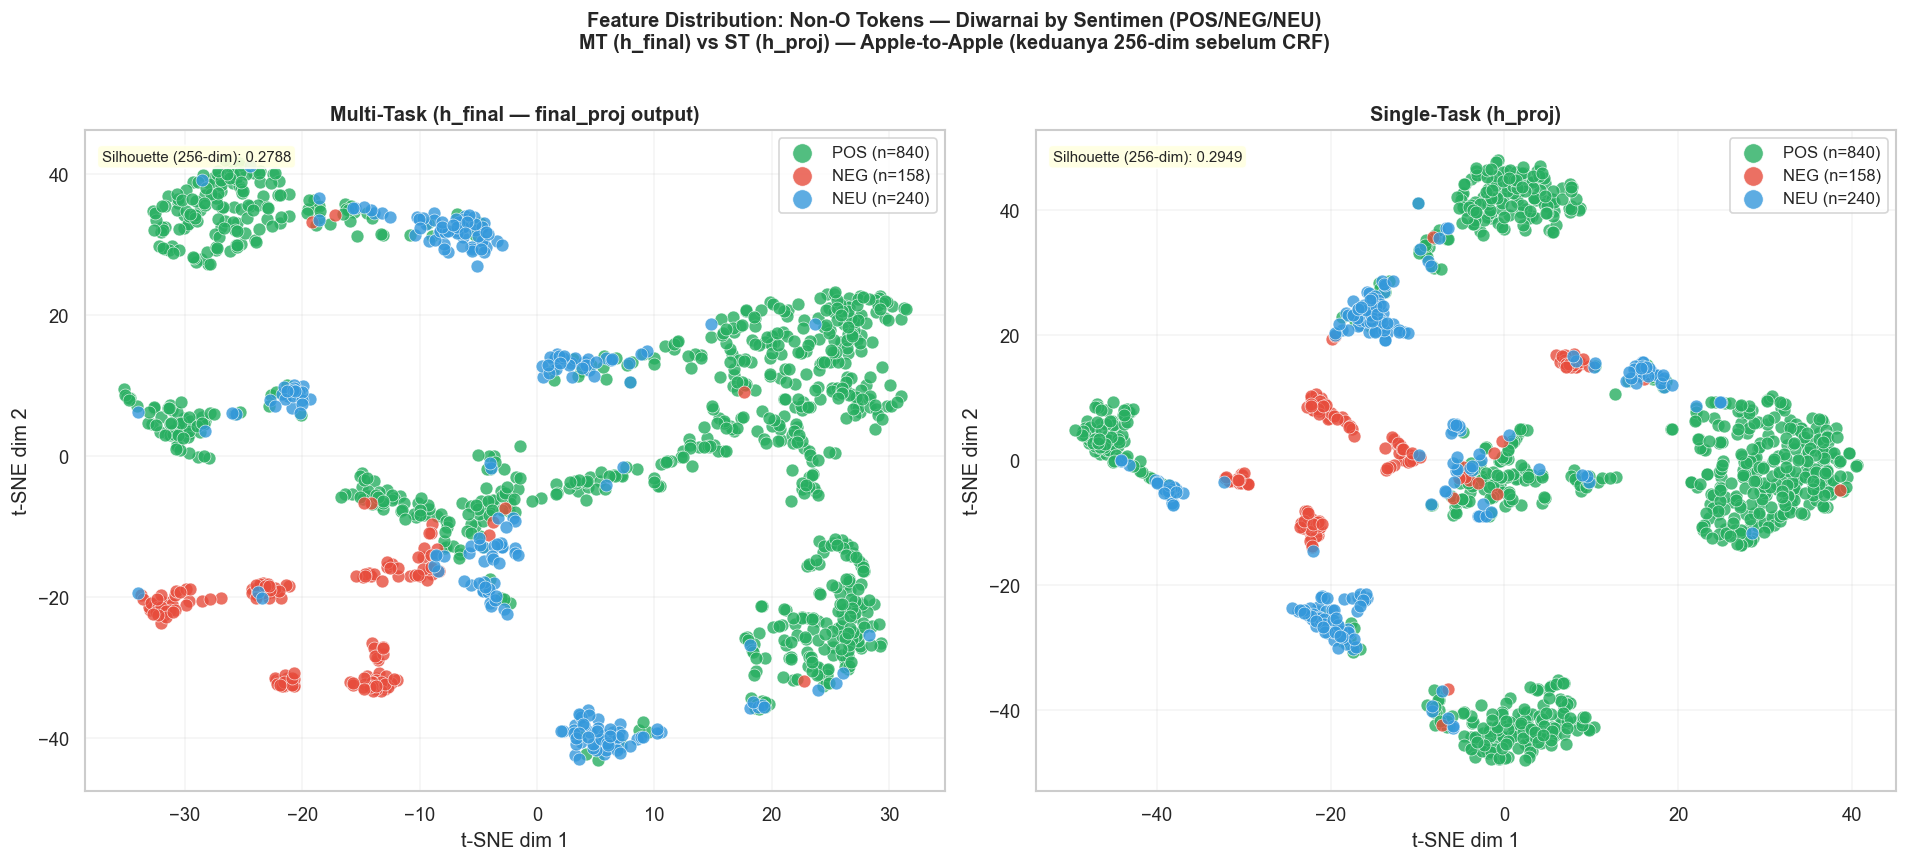

Silhouette Score (cosine, 256-dim) — sentiment separation:
  MT (h_final): 0.2913
  ST (h_proj): 0.3033

Interpretasi: nilai lebih tinggi = cluster sentimen lebih terpisah dan compact


In [37]:
from sklearn.metrics import silhouette_score

# Derivasikan label sentimen dari BIEOS label (ambil bagian setelah '-')
nonO_sentiments = np.array([lbl.split('-')[1] for lbl in nonO_labels])
sent_colors = {'POS': '#27ae60', 'NEG': '#e74c3c', 'NEU': '#3498db'}
sent_order  = ['POS', 'NEG', 'NEU']

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
plot_data = [
    (axes[0], mt_nonO_2d, mt_nonO_emb, 'Multi-Task (h_final — final_proj output)'),
    (axes[1], st_nonO_2d, st_nonO_emb, 'Single-Task (h_proj)'),
]

for ax, emb_2d, emb_high, title in plot_data:
    for sent in sent_order:
        mask = nonO_sentiments == sent
        ax.scatter(emb_2d[mask, 0], emb_2d[mask, 1],
                   c=sent_colors[sent], s=60, alpha=0.8,
                   edgecolors='white', linewidths=0.4,
                   label=f'{sent} (n={mask.sum()})')
    ax.set_title(title, fontweight='bold', fontsize=12)
    ax.set_xlabel('t-SNE dim 1')
    ax.set_ylabel('t-SNE dim 2')
    ax.legend(fontsize=10, markerscale=1.5)
    ax.grid(True, alpha=0.2)

    # Silhouette score di ruang 256-dim (bukan 2D t-SNE)
    sent_ids = np.array([['POS','NEG','NEU'].index(s) for s in nonO_sentiments])
    if len(np.unique(sent_ids)) > 1:
        sil = silhouette_score(emb_high, sent_ids, metric='cosine', sample_size=min(500, len(sent_ids)), random_state=SEED)
        ax.text(0.02, 0.97, f'Silhouette (256-dim): {sil:.4f}',
                transform=ax.transAxes, fontsize=9, va='top',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.9))

plt.suptitle(
    'Feature Distribution: Non-O Tokens — Diwarnai by Sentimen (POS/NEG/NEU)\n'
    'MT (h_final) vs ST (h_proj) — Apple-to-Apple (keduanya 256-dim sebelum CRF)',
    fontweight='bold', fontsize=12, y=1.02
)
plt.tight_layout()
plt.show()

# Perbandingan silhouette score lengkap
print('Silhouette Score (cosine, 256-dim) — sentiment separation:')
sent_ids = np.array([['POS','NEG','NEU'].index(s) for s in nonO_sentiments])
for label, emb in [('MT (h_final)', mt_nonO_emb), ('ST (h_proj)', st_nonO_emb)]:
    sil = silhouette_score(emb, sent_ids, metric='cosine', random_state=SEED)
    print(f'  {label}: {sil:.4f}')
print()
print('Interpretasi: nilai lebih tinggi = cluster sentimen lebih terpisah dan compact')